In [288]:
import datetime as dt
import pandas as pd
import numpy as np
import warnings
#import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [289]:
def isclose(value, original, tolerance= 0.05):
    return value <= original * (1+tolerance) and value >= original * (1-tolerance)

# Abstract

For this project, I chose the option of making my own trading algorithm. The algorithm in my project relies on Fourier transform to extract patterns of repetition in stock market data. The price of an asset can fluctuate around the fair price for the following reason: when buyers realize the actual price is overvalued compared to its fair, they stop buying and start selling, driving down the price; inversely, when buyers realize the actual price is undervalued compared to its fair, they stop selling and start buying, driving up the price. This behavior would translate into a harmonic motion of sorts around the fair price, and thus the algorithm can take advantage of these differences.

# Methods

The dataset used for this project was the stock_data.parquet file provided for Lab 02. The algorithm is as follows:

Let’s say we have 24 days of data on a single asset's log return behind us. 
1. Using the log returns from the last 24 days, we can try to extract the effective frequency that the log returns of the asset fluctuates at. To do this, we fit data points from 24 days ago until to 12 days ago with multiple periodic functions, one with period 7, one with period 8, …, and one with a period of 12 days. 
2. For each of these functions:
    1. We can decide to filter out frequencies that aren't as strong as others.
    3. We need to measure how effectively it can predict the log returns within the last 12 days. To do this, the function is extended to cover the last 12 days, and the MSE metric is used to measure how closely the periodic function can predict the last 12 days.
3. We select the periodic function with the least MSE. Note that the frequency of this function is the effective frequency of oscillation within the data locally (in the last 12 days).
4. With the chosen periodic function, we can then try to predict the forward log return (the log return of the next day) by extending the periodic function into the next day. The position we have for the current day will be proportional to this predicted forward log return.

![]()

# Results

In each of the cells below is an image of the returns of the strategy along with a description of the conditions used.

1. In the Fourier analysis in Step 2.1, no frequencies were filtered out. This is virtually the same as using the raw log return data points from before 12 days ago and measuring their ability to predict the data points within the last 12 days. 
![](0.png)


2. In the Fourier analysis in Step 2.1, frequencies that had an amplitude \<25% than the frequency with the maximum amplitude were filtered out.
![](0.25.png)


3. In the Fourier analysis in Step 2.1, frequencies that had an amplitude \<50% than the frequency with the maximum amplitude were filtered out.
![](0.5.png)


4. In the Fourier analysis in Step 2.1, frequencies that had an amplitude \<75% than the frequency with the maximum amplitude were filtered out.
![](0.75.png)

We see that the returns get progressively worse as we filter out more and more frequencies from each selected function in Step 2.1.

I also experimented with Step 1, by trying different ranges of periods for the different periodic functions to test. I initially tried different periodic functions, with periods ranging from 7 days to 12 days. In the following trials, I also tried period ranges of 4 to 7, 5 to 9, 8 to 15, 10 to 18, 11 to 21, 13 to 24, 14 to 27, and 16 to 30. For each of the following trials, no filtering was performed in Step 2.1, as that yielded the best results for the original experiment. 
Note: Each period range is of the form `n` to `2n-1` or `n` to `2n-2` because there is no use in testing periods below `n`. For example, a function that has period `n-1` also has a period of `2n-2`, which is already included in the period range. Similarly, all functions with smaller periods would have been taken care of by fitting functions with periods in the interval `n` to `2n-1` or `2n-2`.

Fitting functions with period of 4 days to 7 days:
![](7d-4d-0.0.png)

Fitting functions with period of 5 days to 9 days:
![](9d-5d-0.0.png)

Fitting functions with period of 8 days to 15 days:
![](15d-8d-0.0.png)

Fitting functions with period of 10 days to 18 days:
![](18d-10d-0.0.png)

Fitting functions with period of 11 days to 21 days:
![](21d-11d-0.0.png)

Fitting functions with period of 13 days to 24 days:
![](24d-13d-0.0.png)

Fitting functions with period of 14 days to 27 days:
![](27d-14d-0.0.png)

Fitting functions with period of 16 days to 30 days:
![](30d-16d-0.0.png)

When compared with the original algorithm, log returns for these approaches seem to mostly perform worse and fluctuate wildly. However, using a period range of 8 to 15 gets us a log return close to 0.04, and and using a period range of 10 to 18 gets us a log return of around 0.05, which is better than our original period range of 6 to 12. This tells us that taking into account much longer periods, like 18 days or larger, and excluding periods in the range from 6 to 18 causes the algorithm to perform worse and have less predictive power.

# Conclusion

In comparison to the momentum based trading strategy shown in Lab 02, this algorithm has a similar ending log return of around 0.04, and the returns seem to fluctuate less for this algorithm.

However, this algorithm doesn't perform nearly as well as the equal position strategy. The image below compares all three strategies.

img

# Please see my code in the section **My Strategy**

In [290]:
# see if you can derive the transformations from log returns to simple returns, and simple returns to log returns
hdf = pd.read_parquet('/Users/ishwar/Desktop/IEOR198 Final/stock_data.parquet')
hdf.head()

Price        Adj Close                                                        \
Ticker               A    AAL        AAPL        ABBV        ABNB        ABT   
Date                                                                           
2023-10-04  110.917877  12.73  172.585999  141.069550  127.410004  93.262283   
2023-10-05  109.606766  12.85  173.828293  140.840302  124.989998  93.798546   
2023-10-06  109.894814  12.76  176.392334  141.594879  126.360001  94.461571   
2023-10-09  110.530510  12.24  177.883041  142.425888  127.769997  94.344574   
2023-10-10  112.526970  12.26  177.286758  142.215759  131.589996  95.124588   

Price                                                      ...  Volume  \
Ticker           ACGL         ACN        ADBE         ADI  ...     WTW   
Date                                                       ...           
2023-10-04  76.509293  303.237457  518.419983  170.809814  ...  749100   
2023-10-05  77.631355  303.502045  516.440002  169.148819  ...  855000   
2023-10-06  78.144844  305.981781  526.679993  170.986740  ...  897700   
2023-10-09  78.040245  305.805359  529.289978  170.347885  ...  655500   
2023-10-10  77.840553  306.109161  532.719971  172.952438  ...  478400   

Price                                                                       \
Ticker           WY     WYNN      XEL       XOM      XYL      YUM      ZBH   
Date                                                                         
2023-10-04  3954000  2289300  3948700  19622200  1614400  1381200  1597600   
2023-10-05  3724500  1513600  3835400  20128800  1131000  1240200  1048200   
2023-10-06  4318300  2470600  6337200  25363400  1149700  2111900  1570500   
2023-10-09  3171800  1622800  2702100  22369900   949500  1840000   865900   
2023-10-10  3078500  1674800  3117900  13892000  1478800  1643300   999400   

Price                        
Ticker        ZBRA      ZTS  
Date                         
2023-10-04  487500  1673400  
2023-10-05  448400  2083200  
2023-10-06  384000  1490600  
2023-10-09  266600  1215100  
2023-10-10  361900  1665300  

[5 rows x 994 columns]

In [291]:
# use np.exp
def logtosimple(logreturn):
    return np.exp(logreturn) - 1

In [292]:
# use np.log
def simpletolog(simplereturn):
    return np.log(simplereturn + 1)

In [293]:
# let's look at an example asset
# create a dataframe that is just the adjusted close and volume for AAL
aal = hdf.loc[:,hdf.columns.get_level_values(1) == "AAL"]
aal.head()

Price,Adj Close,Volume
Ticker,AAL,AAL
Date,,
2023-10-04,12.73,49738100
2023-10-05,12.85,36272900
2023-10-06,12.76,31822200
2023-10-09,12.24,51462700
2023-10-10,12.26,37144200


Let's remove the top level of the columns in order to make things easier - we already know the symbol is AAL

In [294]:
aal.columns = aal.columns.get_level_values(0)
print(aal.columns)
aal.head()

Index(['Adj Close', 'Volume'], dtype='object', name='Price')


Price,Adj Close,Volume
Date,,
2023-10-04,12.73,49738100
2023-10-05,12.85,36272900
2023-10-06,12.76,31822200
2023-10-09,12.24,51462700
2023-10-10,12.26,37144200


To calculate returns for **AAL**, create a new column by applying `.pct_change()` to the **adjusted close** column.

In [295]:
aal['returns'] = aal["Adj Close"].pct_change()
aal.head()

Price,Adj Close,Volume,returns
Date,,,
2023-10-04,12.73,49738100,NaN
2023-10-05,12.85,36272900,0.009427
2023-10-06,12.76,31822200,-0.007004
2023-10-09,12.24,51462700,-0.040752
2023-10-10,12.26,37144200,0.001634


In [296]:
# we can get the log returns by adjusting the percent change function

aal['logreturns'] = aal['returns'].apply(simpletolog)
aal.head()

Price,Adj Close,Volume,returns,logreturns
Date,,,,
2023-10-04,12.73,49738100,NaN,NaN
2023-10-05,12.85,36272900,0.009427,0.009382
2023-10-06,12.76,31822200,-0.007004,-0.007029
2023-10-09,12.24,51462700,-0.040752,-0.041606
2023-10-10,12.26,37144200,0.001634,0.001633


In [297]:
# .cumsum() on a series will add everything in the column up until that point
# this will give us the log return from the start, to the current index
aal['cum_logreturns'] = aal["logreturns"].cumsum()
aal.head()

Price,Adj Close,Volume,returns,logreturns,cum_logreturns
Date,,,,,
2023-10-04,12.73,49738100,NaN,NaN,NaN
2023-10-05,12.85,36272900,0.009427,0.009382,0.009382
2023-10-06,12.76,31822200,-0.007004,-0.007029,0.002354
2023-10-09,12.24,51462700,-0.040752,-0.041606,-0.039252
2023-10-10,12.26,37144200,0.001634,0.001633,-0.037619


115


<Axes: xlabel='Date'>

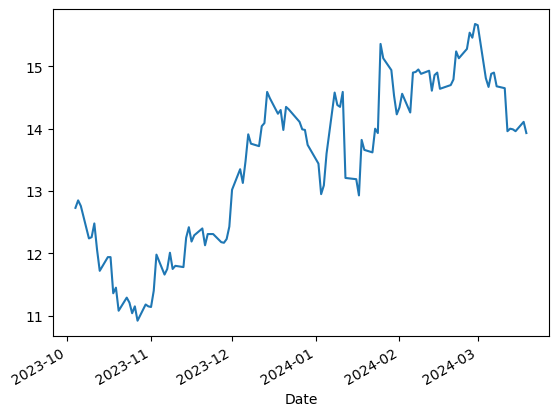

In [298]:
# pandas also comes equipped with some built in plotting
# we can plot the adjusted close, as well as the logreturns cumsum, and see if they look the same (they should)
print(len(aal['Adj Close']))
aal['Adj Close'].plot()

<Axes: xlabel='Date'>

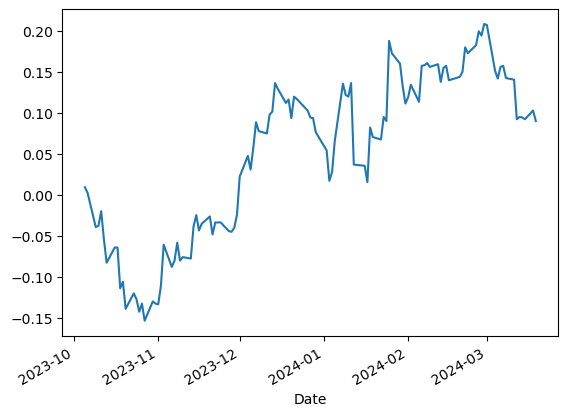

In [299]:
aal['cum_logreturns'].plot()

# Basic trend strategy: long/short by percentile

---
### Developing a Trading Strategy

Now, let’s work on creating a **trading strategy** with the following assumptions:

- **Shorting Allowed**: We assume that we can short stocks.
- **Zero Borrowing Cost**: For simplicity, we assume the cost to borrow is **0** (note: this is a non-trivial assumption).

#### Strategy Overview
Our goal is to:
- **Buy (go long)** stocks expected to increase in value.
- **Sell (go short)** stocks expected to decrease in value.

#### Approach
1. **Ranking Stocks**:  
   We will rank stocks based on a chosen **metric** (e.g., momentum, valuation ratios, or other factors).

2. **Position Allocation**:  
   - Go **long** on the top percentage of stocks ranked by the metric.
   - Go **short** on the bottom percentage of stocks ranked by the metric.

This approach allows us to systematically identify opportunities and construct a portfolio based on clear criteria.

---

In [ ]:
hdf

In [ ]:
# to more easily group by asset, we'll make assets into its own column using df.stack()
hdf_old = hdf.copy()
hdf = (
    hdf.stack()
    .reset_index()
    .rename(columns={'level_1': 'Symbol'})
)
hdf

### Calculating Returns and Log Returns

To compute **returns** and **log returns** for the entire dataset, we can **group by the ticker**, select the adjusted close column, and then use .pct_change() to get the percentage change from one row to the next

These steps will provide the necessary data to derive both simple and log returns for analysis. 

In [ ]:
hdf.groupby('Ticker')['Adj Close'].pct_change()

In [ ]:
hdf['returns'] = hdf.groupby('Ticker')['Adj Close'].pct_change()
hdf.head()

### Creating a Log Returns Column

To calculate log returns, we'll create a new column in the dataset. This involves applying our **simple-to-log** function to the data and assigning the results to a column named `logreturns`.

This new column will represent the log-transformed returns for each data point.

In [ ]:
hdf['logreturns'] = hdf['returns'].apply(simpletolog)
hdf.head()

### Creating a Forward Log Return Column

To predict the next step of returns, we need to create a column for the **forward log return**. Here's how to do it:

1. **Group by Ticker**: Group the data by the stock ticker to ensure calculations are performed within each stock's data.

2. **Select Log Returns**: Focus on the column containing the log returns.

3. **Shift the Series**: Use `.shift(-1)` to move the series **up one row**, aligning the future return with the current row.  
   Refer to the [pandas.DataFrame.shift documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html) for more details.

This process creates a new column that represents the **forward log return**, which can be used as the target variable for prediction models.

In [ ]:
hdf['fwd_logreturn'] = hdf.groupby('Ticker')['logreturns'].shift(-1)
hdf.head()

### Dropping Rows with NaN Values

To avoid issues in future operations, we need to drop rows where **log returns** or **forward log returns** contain `NaN` values. This can be done using the `subset` parameter in `df.dropna(subset=[])`

In [ ]:
hdf = hdf.dropna(subset=['logreturns', 'fwd_logreturn'])
hdf.head()

# Momentum

---

### Ranking Returns by Asset

To develop a strategy, we can **rank the returns** for each asset. But first, we need to decide:  

**What metric should we use for ranking?**

#### Observations:
- **Momentum Tendency**:  
  We might guess that stocks that have **gone up** tend to continue rising, while stocks that have **gone down** tend to keep falling.  

#### Why Might This Happen?  
This behavior makes economic sense:
- A stock that has risen significantly might attract buyers who want to **join the trend**, driving the price higher.
- Conversely, a stock that has fallen may face additional selling pressure from investors exiting their positions.

#### Strategy:
- **Buy (Go Long)**: Identify and buy the stocks that have risen the most.  
- **Sell (Go Short)**: Identify and short the stocks that have fallen the most.

---


### Calculating Ranks Using `.rank()`

To calculate ranks for log returns, we can use the `.rank()` method. This method assigns a rank value as if the DataFrame were sorted. Key steps:

1. **Descending Order**: Use `ascending=False` to rank in descending order.
2. **Dense Ranking**: Specify `method='dense'` to ensure that ranks are consecutive even when there are ties.
3. **Group by Date**: Group the data by date to calculate ranks within each group.
4. **Assign to a New Column**: Create a new column, `logreturn_rank`, to store the ranks of the `logreturns` column.

Refer to the [pandas.DataFrame.rank documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rank.html) for more details.

In [ ]:
hdf['logreturn_rank'] = hdf.groupby('Date')['logreturns'].rank(ascending=False, method='dense')
hdf.head()

In [ ]:
pd.set_option('display.max_rows', 200)
#hdf.groupby('Ticker').get_group("AAL")
hdf.groupby('Date').get_group("2023-10-05").sort_values(by=['logreturn_rank'])

In [ ]:
# we can also look at the demeaned returns, or the returns of the asset we chose relative to all assets
# this will help us assess if we were able to choose the assets that would end up under/overperforming

date_mean_logreturns = hdf.groupby('Date')['logreturns'].transform('mean')

# Calculate the demeaned log returns
hdf['demeaned_logreturn'] = hdf['logreturns'] - date_mean_logreturns

# Similar to the above, calculate the mean *forward* log returns for each date
date_mean_fwd_logreturns = hdf.groupby('Date')['fwd_logreturn'].transform('mean')

# Calculate the demeaned forward log returns
hdf['demeaned_fwd_logreturn'] = hdf['fwd_logreturn'] - date_mean_fwd_logreturns
hdf.head()

In [ ]:
# for ease of analyzing the effect, we will bucket our feature using a decile (each bin is 10%-ile)
# this will help us figure out how strong the effect is
# we do this using pd.qcut(x, q=quantile, labels=False, duplicates='drop'), which cuts a series into quantile buckets. pass q=10 to get decile buckets
# [https://pandas.pydata.org/docs/reference/api/pandas.qcut.html]
# drop labels and duplicates
hdf['logreturn_decile'] = hdf.groupby('Date')['logreturns'].transform(
    lambda x: pd.qcut(x, q=10, labels=False, duplicates='drop'))
hdf.head()

In [ ]:
hdf.groupby('logreturn_decile').mean(numeric_only = True)['demeaned_fwd_logreturn']

In [ ]:
# we'll plot this using a barplot
hdf.groupby('logreturn_decile').mean(numeric_only = True)['demeaned_fwd_logreturn'].plot(kind='bar')

In [ ]:
# it definitely looks like the bottom and top 20%-ile have outsized returns!

# Strategy 'backtesting'

---

### Backtesting: A Simplified Approach

While backtesting is a valuable tool, it can sometimes be excessive when conducting an **initial test** to evaluate whether a feature is useful. Instead, we’ll start with a **basic backtest** using the following assumptions:

1. **No Trading Costs**:  
   - We'll ignore trading costs for now.  
   - Although trading costs are a significant drag on profitability, they're not critical for this initial test.

2. **Key Idea**:  
   - If a strategy **doesn’t work** without trading costs, it’s unlikely to work **with** trading costs included.

This simplified backtest provides a quick way to assess the viability of features before diving into more complex analyses.

--- 

In [ ]:
# let's define our strategy by setting an asset to be long or short if its in the top or bottom 20% log return decile
# we'll also equal weight all our positions
# the decile values for the bottom 20% would be 0 and 1
# the decile values for the top 20% would be 8 and 9

# we can use np.where() in order to conditionally assign a column
def longorshort(d):
    if d in [0, 1]:
        return 1
    elif d in [8, 9]:
        return -1
    else:
        return 0
hdf['long/short'] = hdf["logreturn_decile"].apply(longorshort)
hdf.head()

In [ ]:
# we size our positions by taking our absolute long/short position
hdf['absposition'] = np.abs(hdf["long/short"])
hdf.head()

In [ ]:
# getting the total number of our positions by summing our absolute position for each day 
# hint: take a look at .transform documentation [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.transform.html]
hdf['numpositions'] = hdf.groupby('Date')['absposition'].transform('sum')
hdf.head()

In [ ]:
# and we get our final weight for each asset by scaling our long/short indicator variable by the number of positions we have
# each position should be such that we add up to one, so we'd divide the indicator by total positions
# if we have 0 positions, the weight should be 0
# this will mean that we should have equal size long and short, adding up to a total of 1 (no leverage)
# we'll use df.apply(lambda row: (expression using row) if (condition on some row) else value, axis=1)

hdf['weight'] = hdf['long/short'] / hdf['numpositions']
hdf.head()

In [ ]:
# finally we define the strategy's return as the weighted logreturns based on our position
# so we multiply weight by forward logreturn
hdf['strategy_logreturn'] = hdf['weight'] * hdf['fwd_logreturn']
hdf.head()

In [ ]:
# we can compare this with an equal weighted strategy, where we long each asset the same amount, again summing up to 1
# hint: use .unique() to get number of assets [https://pandas.pydata.org/docs/reference/api/pandas.unique.html]

hdf['eqweight'] = 1 / len(pd.unique(hdf['Ticker']))
hdf['equal_logreturn'] = hdf['eqweight'] * hdf['fwd_logreturn']
hdf.head()

# Evaluating performance

<Axes: xlabel='Date'>

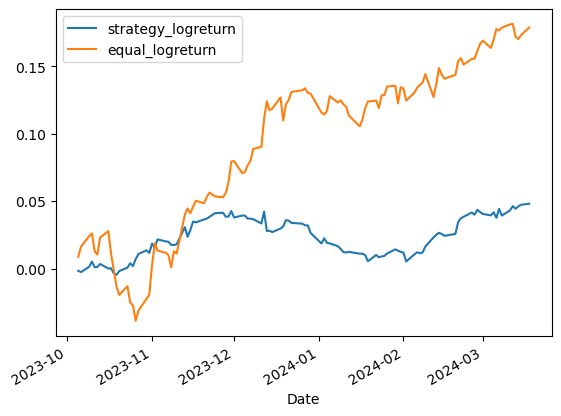

In [163]:
hdf.groupby('Date').sum()['strategy_logreturn'].cumsum().plot(legend=True)
hdf.groupby('Date').sum()['equal_logreturn'].cumsum().plot(legend=True)

In [ ]:
# we can get the final return by getting the last value of the column (values[-1])
# and we can translate that to simple returns for readability
final_strategyreturn = logtosimple(hdf.groupby('Date').sum()['strategy_logreturn'].cumsum().values[-1])
final_equalreturn = logtosimple(hdf.groupby('Date').sum()['equal_logreturn'].cumsum().values[-1])

print(f'final_strategyreturn: {final_strategyreturn}')
print(f'final_equalreturn: {final_equalreturn}')

---

### Evaluating Strategy Performance

The equal-weight strategy significantly outperformed our strategy. Given the simplicity of our approach, this outcome is not unexpected. However, the equal-weight strategy also exhibited notable **volatility**. 

To better account for volatility, we can use the **Sharpe Ratio**. 

#### Understanding the Sharpe Ratio
The Sharpe Ratio measures the **risk-adjusted return** of a strategy and can be thought of as a t-test for the statistical significance of the returns. It is calculated as:  

$$ \text{Sharpe Ratio} = \frac{\text{Mean Return} - \text{Risk-Free Rate}}{\text{Standard Deviation of Returns}}$$

Benerally, any sharpe ratio over 1 is good, 2 is very good, 3+ is very very good. As you see a sharpe ratio > 3, the more likely that the strategy is somehow limited, or you've calculated something wrong

#### Important Caveats
In this example, the calculated Sharpe Ratios are **not realistic** due to several simplifications. For instance:
- **Lookahead Bias**: Restricting the universe to companies currently in the S&P 500 introduces bias, as we are using information unavailable in past periods (e.g., in 2023).

There are likely other ways this sample or testing strategy might be limited. Consider exploring additional potential biases or flaws in the approach!

--- 

In [ ]:
# let's calculate the sharpe ratio with a function, we'll leave out the risk free rate part of it for now
# we also need to normalize the sharpe ratio with respect to a year, by multiplying by the square root of periods our strategy trades in a year
# note that there are 252 trading days

def sharpe_ratio(mean_ret, std_ret):
    return (mean_ret / std_ret) * np.sqrt(252)
    
strat_sharpe = sharpe_ratio(hdf.groupby('Date').sum()['strategy_logreturn'].mean(), \
            hdf.groupby('Date').sum()['strategy_logreturn'].std())
equal_sharpe = sharpe_ratio(hdf.groupby('Date').sum()['equal_logreturn'].mean(), \
            hdf.groupby('Date').sum()['equal_logreturn'].std())
print(strat_sharpe, equal_sharpe)

# My strategy

**Fourier analysis on log returns**

In [ ]:
len(pd.unique(hdf["Date"]))

In [ ]:
pd.unique(hdf["Ticker"])

In [ ]:
# take a single asset
# take the list of log returns associated with the asset
aapl = hdf.groupby("Ticker").get_group("EQR")["logreturns"]
#aapl = aapl[0:len(aapl)//2]
aapl = aapl.to_numpy()
# plot it

# take the first half and perform fft
def perform_fft(sequence):
    # Perform the Fast Fourier Transform
    fft_result = np.fft.fft(sequence)
    # Compute the corresponding frequencies
    n = len(sequence)
    freq = np.fft.fftfreq(n)
    return freq, fft_result
def recover_signal(fft_result):
    # Perform the Inverse Fast Fourier Transform to recover the original signal
    recovered_signal = np.fft.ifft(fft_result)
    return np.real(recovered_signal)  # Return only the real part (original signal)
def extrapolate_signal(fft_result, num_points):
    # Extend the FFT result by zero-padding to extrapolate the time series
    n = len(fft_result)
    extended_fft = np.zeros(num_points, dtype=complex)
    extended_fft[:n] = fft_result

    # Perform the inverse FFT on the extended data
    extrapolated_signal = np.fft.ifft(extended_fft)
    return np.real(extrapolated_signal)  # Return only the real part

"""
window_len = 24
freq, fft_result = perform_fft(aapl[:window_len])
fft_result[7:len(aapl)-7] = 0
#print(fft_result)
#print(freq)
aapl_fourier = recover_signal(fft_result)

plt.plot(range(0, len(aapl_fourier))[:window_len], aapl[:window_len])
print(len(aapl))
plt.plot(range(0, len(aapl_fourier))[:window_len], aapl_fourier[:window_len])
plt.legend(loc="upper right")
plt.show()

plt.plot(range(0, len(aapl)), aapl)
print(len(aapl) // window_len)
#print(np.concatenate(2 * (aapl_fourier,)))
plt.plot(range(0, len(aapl)), np.concatenate((1 + len(aapl)//window_len)*(aapl_fourier,))[0:len(aapl)] )
plt.legend(loc="upper right")
plt.show()
"""

"""
plt.plot(freq[:len(freq)//2], np.abs(fft_result)[:len(freq)//2])
plt.title("FFT Result (Magnitude)")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.show()
"""
# plot the waveform from the fft onto the full data and see if there is any predictive power

# Experiments to complete
* Low pass filter
* High pass filter
* High pass filter + adjusting using last data point
* Normal fft -- equivalent to comparing data directly across period

* Cutoff values

* wavelengths to cut off

* keep wavelengths to test constant in [13, 14, .., 24]

In [ ]:
"""
# for a particular date 
def calculate_single_position(windowed_series):
    window_lens = range(24, 12, -1)
    pstn_vote = []
    for l in window_lens:
        freq, fft_result = perform_fft(windowed_series[-l:])
        fft_result[6:l-6] = 0
        #print(fft_result)
        #print(freq)
        lowpass_signal = recover_signal(fft_result)
    
        pstn = 0
        if lowpass_signal[0] > 0:
            # position is 1
            pstn = 1
        elif lowpass_signal[0] < 0:
            # position is -1
            pstn = -1
        
        pstn_vote.append(pstn)

    if pstn_vote.count(1) > 4:
        return 1
    elif pstn_vote.count(-1) > 4:
        return -1
    else:
        return 0
"""

def calculate_single_position_2(windowed_series):
    window_lens = range(24, 12, -1)
    mses = []
    ls = []
    signals = []
    for l in window_lens:
        # perform fft on a window of length l, excluding 5 data points after it
        freq, fft_result = perform_fft(windowed_series[-l-5:-5])
        # eliminate high frequency components with wavelength <= 3
        
        cutoff_wavelength = 5
        cutoff_freq = 1/cutoff_wavelength
        cutoff_n = l // cutoff_wavelength
        fft_result[:cutoff_n:] = 0
        fft_result[l-cutoff_n:] = 0
        
        #print(fft_result)
        #print(freq)
        lowpass_signal = recover_signal(fft_result)
        #lowpass_signal = windowed_series[-l-5:-5]

        # measure how close the last 5 data points match up with the first 5 values of the lowpass signal
        extended_signal = np.concatenate((lowpass_signal, lowpass_signal[:6]))
        mse = np.mean(np.square(extended_signal[-6:-1] - windowed_series[-5:]))
        mses.append(mse)
        ls.append(l)
        signals.append(lowpass_signal)
    #print(mses)
    #print(ls)
    #print([s.shape for s in signals])
    
    # find effective frequency of data points
    min_error = 1e9
    min_i = -1
    for i in range(len(mses)):
        if mses[i] < min_error:
            min_error = mses[i]
            min_i = i

    plt.plot(range(0, len(l)), )
    plt.plot(range(0, len(aapl_logreturns)), aapl_positions / 100)
    plt.legend(loc="upper right")
    plt.show()

    predicted_logreturn = signals[min_i][5] - signals[min_i][4] + windowed_series[-1]
    if signals[min_i][5] > 0:
        return 1
    elif signals[min_i][5] < 0:
        return -1
    else:
        return 0


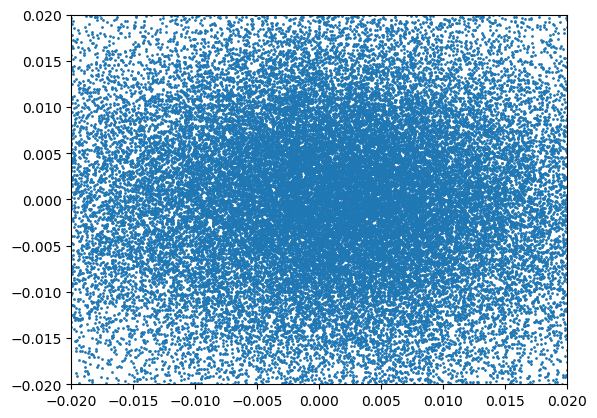

In [157]:
plt.scatter(hdf["logreturns"], hdf["demeaned_fwd_logreturn"], s=1)
#local_x = # np values spaced by 0.0025
#local_avgy = # average of demeaned_fwd_logreturns in that range
plt.xlim(-0.02, 0.02)
plt.ylim(-0.02, 0.02)
plt.show()

# Experiments

Frequencies tested: 1/12 days^-1 to 1/6 days^1
Filtering methods
* Keeping frequencies with an amplitude >50% of the predominant frequency
* Keeping frequencies with an amplitude >75% of the predominant frequency 
* Keeping frequencies with an amplitude >25% of the predominant frequency 
* Keeping all frequencies (equivalent to not doing a Fourier analysis and straight-up copying the original signal)

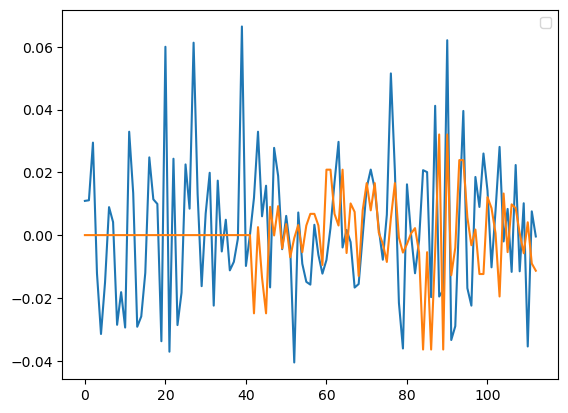

In [279]:
# eliminate high frequency components with wavelength <= 3
"""
cutoff_wavelength = 5
cutoff_freq = 1/cutoff_wavelength
cutoff_n = l // cutoff_wavelength
fft_result[:cutoff_n:] = 0
fft_result[l-cutoff_n:] = 0
"""

def predict_fwd_logreturn(windowed_series):
    window_lens = range(30, 15, -1)
    test_len = 12
    mses = []
    ls = []
    signals = []
    for l in window_lens:
        # perform fft on a window of length l, excluding 5 data points after it
        to_fit = windowed_series[-l-test_len:-test_len]
        freq, fft_result = perform_fft(to_fit)

        # remove insignificant frequency components
        #max_amp = np.max(np.abs(fft_result))
        #fft_result[np.abs(fft_result) < max_amp * 0.625] = 0

        # reconstruct original signal
        lowpass_signal = recover_signal(fft_result)

        extended_signal = np.concatenate(((l+test_len+1+ l) // l)*(lowpass_signal,))[:l+test_len+1] # extend lowpass_signal to include next 5 days and the 6th day to be predicted
        #print(l)
        #print(len(extended_signal))

        # measure how close the last 5 data points match up with the first 5 values of the lowpass signal
        mse = np.mean(np.square(extended_signal[-test_len-1:-1] - windowed_series[-test_len:]))
        mses.append(mse)
        ls.append(l)
        signals.append(extended_signal)

    # find effective frequency of data points
    min_error = 1e9
    min_i = -1
    for i in range(len(mses)):
        if mses[i] < min_error:
            min_error = mses[i]
            min_i = i

    #print("Freq: ", ls[min_i])
    #plt.plot(range(ls[min_i]+test_len), windowed_series[-ls[min_i]-test_len:])
    #plt.plot(range(ls[min_i]+test_len), signals[min_i][:-1])
    #plt.legend(loc="upper right")
    #plt.show()

    return signals[min_i][-1]

# assumed for one asset
def calculate_positions(single_asset):
    #g = data.groupby('Ticker')
    #tickers = g.groups.keys()
    #print(tickers)
    #grp_name = "AAPL"
    #single_asset = g.get_group(grp_name)
    
    fwds_list = np.zeros(single_asset.shape[0])
    window_len = 42
    for i in range(window_len, len(fwds_list)):
        #print(f"Day {i}")
        window_logreturns = single_asset[i-window_len:i].to_numpy()
        #pstn = calculate_single_position(window_logreturns)
        fwd = predict_fwd_logreturn(window_logreturns)
        fwds_list[i] = fwd
    #print(positions)
    return fwds_list

asset_fwdlogreturns = hdf.groupby("Ticker").get_group("ABNB")["fwd_logreturn"]
asset_fwd = calculate_positions(hdf.groupby("Ticker").get_group("AAPL")["logreturns"])

plt.plot(range(0, len(asset_fwdlogreturns)), asset_fwdlogreturns)
plt.plot(range(0, len(asset_fwdlogreturns)), asset_fwd)
plt.legend(loc="upper right")
plt.show()

#hdf["newstrat_longshort"] = hdf.groupby("Ticker")["logreturns"].transform(calculate_positions)

In [280]:
hdf["newstrat_predictedlogret"] = hdf.groupby("Ticker")["logreturns"].transform(calculate_positions)

In [281]:
hdf.tail(10)

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn,logreturn_rank,demeaned_logreturn,demeaned_fwd_logreturn,...,numpositions,weight,strategy_logreturn,eqweight,equal_logreturn,newstrat_predictedlogret,newstrat_abspos,newstrat_totalpos,newstrat_weight,newstrat_logreturn
56648,2024-03-18,WTW,271.214355,402800.0,0.006876,0.006853,-0.003219,149.0,0.003870,-0.008853,...,200,0.000,-0.000000,0.002012,-0.000006,0.012738,0.000146,7.371799,0.000020,-6.354070e-08
56649,2024-03-18,WY,33.697689,3373100.0,-0.005243,-0.005257,0.011066,401.0,-0.008240,0.005432,...,200,0.005,0.000055,0.002012,0.000022,0.013501,0.008146,7.371799,0.001105,1.222817e-05
56650,2024-03-18,WYNN,97.998962,1528700.0,-0.002523,-0.002526,0.009165,360.0,-0.005509,0.003531,...,200,0.000,0.000000,0.002012,0.000018,0.005348,0.018238,7.371799,-0.002474,-2.267384e-05
56651,2024-03-18,XEL,51.073341,7217700.0,0.000962,0.000961,0.007466,283.0,-0.002021,0.001832,...,200,0.000,0.000000,0.002012,0.000015,0.010420,0.010420,7.371799,0.001414,1.055389e-05
56652,2024-03-18,XOM,109.604904,16770500.0,0.009257,0.009214,0.007010,109.0,0.006232,0.001376,...,200,0.000,0.000000,0.002012,0.000014,-0.009493,0.003941,7.371799,0.000535,3.747243e-06
56653,2024-03-18,XYL,126.820251,720000.0,0.001729,0.001727,0.007502,263.0,-0.001256,0.001868,...,200,0.000,0.000000,0.002012,0.000015,-0.011678,0.000637,7.371799,0.000086,6.478332e-07
56654,2024-03-18,YUM,134.930374,2384500.0,-0.004165,-0.004174,0.007457,382.0,-0.007157,0.001823,...,200,0.000,0.000000,0.002012,0.000015,0.005845,0.005845,7.371799,0.000793,5.913093e-06
56655,2024-03-18,ZBH,125.166573,972300.0,0.006312,0.006292,0.005542,162.0,0.003309,-0.000092,...,200,0.000,0.000000,0.002012,0.000011,-0.000392,0.000392,7.371799,-0.000053,-2.946278e-07
56656,2024-03-18,ZBRA,285.970001,329300.0,0.000385,0.000385,-0.002731,295.0,-0.002598,-0.008365,...,200,0.000,-0.000000,0.002012,-0.000005,0.000040,0.000040,7.371799,0.000005,-1.498495e-08
56657,2024-03-18,ZTS,169.399384,4955000.0,-0.010894,-0.010954,0.013211,461.0,-0.013937,0.007577,...,200,0.005,0.000066,0.002012,0.000027,0.005960,0.069469,7.371799,-0.009424,-1.244980e-04


In [282]:
# give weights to newstrat weights
hdf["newstrat_abspos"] = hdf.groupby("Date")["newstrat_predictedlogret"].transform(np.abs)
hdf["newstrat_totalpos"] = hdf.groupby("Date")["newstrat_abspos"].transform(np.sum)
hdf["newstrat_weight"] = hdf["newstrat_predictedlogret"] / hdf["newstrat_totalpos"]

In [283]:
hdf.tail()

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn,logreturn_rank,demeaned_logreturn,demeaned_fwd_logreturn,...,numpositions,weight,strategy_logreturn,eqweight,equal_logreturn,newstrat_predictedlogret,newstrat_abspos,newstrat_totalpos,newstrat_weight,newstrat_logreturn
56653,2024-03-18,XYL,126.820251,720000.0,0.001729,0.001727,0.007502,263.0,-0.001256,0.001868,...,200,0.000,0.000000,0.002012,0.000015,-0.011678,0.011678,7.566693,-0.001543,6.478332e-07
56654,2024-03-18,YUM,134.930374,2384500.0,-0.004165,-0.004174,0.007457,382.0,-0.007157,0.001823,...,200,0.000,0.000000,0.002012,0.000015,0.005845,0.005845,7.566693,0.000773,5.913093e-06
56655,2024-03-18,ZBH,125.166573,972300.0,0.006312,0.006292,0.005542,162.0,0.003309,-0.000092,...,200,0.000,0.000000,0.002012,0.000011,-0.000392,0.000392,7.566693,-0.000052,-2.946278e-07
56656,2024-03-18,ZBRA,285.970001,329300.0,0.000385,0.000385,-0.002731,295.0,-0.002598,-0.008365,...,200,0.000,-0.000000,0.002012,-0.000005,0.000040,0.000040,7.566693,0.000005,-1.498495e-08
56657,2024-03-18,ZTS,169.399384,4955000.0,-0.010894,-0.010954,0.013211,461.0,-0.013937,0.007577,...,200,0.005,0.000066,0.002012,0.000027,0.005960,0.005960,7.566693,0.000788,-1.244980e-04


In [284]:
# calculate return of this strategy
hdf['newstrat_logreturn'] = hdf['newstrat_weight'] * hdf['fwd_logreturn']

<Axes: xlabel='Date'>

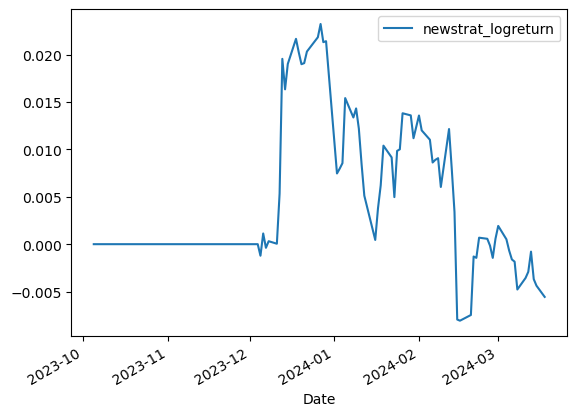

In [285]:
#hdf.groupby('Date').sum()['strategy_logreturn'].cumsum().plot(legend=True)
#hdf.groupby('Date').sum()['equal_logreturn'].cumsum().plot(legend=True)
hdf.groupby('Date').sum()['newstrat_logreturn'].cumsum().plot(legend=True)

---

### Observations on Strategy Performance

Interestingly, the equal-weight strategy showed a very high Sharpe Ratio. This is likely due to the period from October 2023 to March 2024 being particularly bullish. You can verify this by checking the S&P 500 returns during that time.

To minimize the impact of such market-specific idiosyncrasies, it is generally better to backtest over a longer time horizon, such as a year or more. This helps reduce variance and provides a more robust evaluation of the strategy.

--- 

# accounting for fees

In [ ]:
# this is without fees so it is clearly way too good
# let's add a fee for each trade, and expected slippage per trade
# the fee is what we would pay to the broker, and the expected slippage is likely a function of our position size
# we'll combine these into one value, and just observe how our strategy decays as a function of cost

# let's define a percentage fee per trade (e.g., 0.02%)
fee = 0.0002

In [ ]:
hdf["Symbol"]

In [ ]:
# in order to see how large our trade would be, we have to find the difference between our previous and current position size
# we should sort values by symbol, then by the date
hdf = hdf.sort_values(by=['Ticker', 'Date']) # order matters!

# we'll groupby symbol, and then get the previous weight by using .shift(1) to shift the weights down
hdf['prevweight'] = hdf.groupby('Symbol')['weight'] ...

# next, we'll get the strategy's weight change by taking the difference between weight and prevweight
hdf['strategy_weightchange'] = ...

# finally, to calculate fees, we'll need to multiply the fee by our absolute change in position
hdf['strategy_fees'] = abs(hdf['strategy_weightchange']) * fee

In [ ]:
grader.check("q8a")

In [ ]:
# now we'll calculate the strategy log return after fees by subtracting the groupby fees from the groupby logreturn
hdf['strategy_postfees'] = ...
strategy_postfees_seriestoplot = ...
strategy_postfees_seriestoplot.plot()

In [ ]:
grader.check("q8b")

In [ ]:
# and we'll test the sharpe and logreturn as above
fees_sharpe = sharpe_ratio(..., 
                           ...)

In [ ]:
grader.check("q8c")

In [ ]:
# note that the equal weight buy and hold does not change with fees, as it never changes position

# expected returns

In [ ]:
# now that we have a very basic long/short strategy, we should try to improve upon it

# our strategy roughly was equally long and short the market - regardless of how strongly something moved
# even if all of the longs were very high return, the strategy didn't care
# it also didn't care if it was 10th or 20th decile: we gave the same weight regardless
# we might expect that there's a way to improve upon this

# one way of doing this is trying to calculate an 'expected return' for each asset
# this allows us to weight our positions based on how good we think they are

In [ ]:
# how might we make an expected returns model? 
# we'll likely want to fit to some historical data, and see how that strategy performs on data after that

# to avoid our model just learning the optimal answer for our entire dataset
# we'll train the model on the first 80% of our data
# and see how it performs on the remaining 20%

In [ ]:
# split the data into training and testing using .iloc
train_percent = ... # use 80% as a decimal
# make sure to split according to time series!

hdf = hdf.sort_values(...) # order matters! we need to split by time first, then asset

# we can only use integer indices, so make sure to cast the value to an integer
splitrow = ...
training = hdf.iloc[:splitrow]
testing = hdf.iloc[splitrow:]



In [ ]:
grader.check("q9a")

In [ ]:
# a very common basic model is a linear regression: fitting a line to points of data
# given some x variable, we try to solve for the optimal y = mx + b, 
# we do this by minimizing the squared sum of differences of our line to each data point
# luckily there are libraries that do this for us

In [ ]:
# to run a linear regression on our training data, we need a data matrix X of features
# and a target y to fit to 
# in our case, our target is forward log return
# and our data matrix X is the current log returns
# let's run the regression using statsmodels

In [ ]:
feature = [...]
target = [...]

# we add a constant to data matrix Xin order to get an intercept term, otherwise we would be fitting y = mx
X = training[...]
X = sm.add_constant(X)

y = training[...]

model = sm.OLS(y, X).fit()
print(model.params)

In [ ]:
grader.check("q9b")

In [ ]:
# now we can plot our linear regression

m = model.params[...]
b = model.params[...]

# Create a scatter plot
plt.scatter(training[feature], y, color='blue', label='Data')

# Plot the linear regression line
plt.plot(training[feature], m * training[feature] + b, color='red', label='linear regression')

In [ ]:
grader.check("q9c")

In [ ]:
# now we can see how well our model does on our testing data
X_test = sm.add_constant(testing[feature])
y_pred = model.predict(...).values

# we compare the predictions to the actual values
y_test = testing[...].values

# we use mean squared error: the mean difference between y_test and y_pred, squared
mse = ...

In [ ]:
grader.check("q9d")

# updating backtest 

In [ ]:
# we also can look at our model's sharpe ratio on the testing data

In [ ]:

# we can get the expected log returns by applying our model, with a constant, to the feature column

testing['ex_logreturns'] = model.predict(sm.add_constant(...))

# we'll size our weights according to the cross sectional predictions
# use transform again to do this
# we want to have each weight be (ex_logreturn-mean ex_logreturn for date)/(sum of absolute ex_logreturns for date)

testing['ex_weight'] = testing.groupby('Date')['ex_logreturns'].transform(lambda x: ...)

# and we multiply the forward log returns again
testing['exstrategy_logreturns'] = ...

# and we plot once more
testing.groupby('Date').sum()['exstrategy_logreturns'].cumsum().plot()

In [ ]:
grader.check("q10a")

In [ ]:
# wow that looks very promising! let's calculate the sharpe ratio with fees
# sort again
testing = testing.sort_values(...)
# get previous ex_weight as before
testing['prevex_weight'] = ...
# get change in weight as before
testing['exstrategy_weightchange'] = ...

# get absolute change in position
testing['exstrategy_fees'] = ...
# and find the return post fees
testing['exstrategy_postfees'] = ...


In [ ]:
grader.check("q10b")

# feature engineering

In [ ]:
# let's try to add more features to see if we can make this model any better

In [ ]:

# first, let's create a function that makes the bar plot from before, so we can easily view any feature
def summarize_feature(hdf, colname):
    if hdf[colname].dtype == 'float':
        # use qcut here, by deciles as before
        bins = ...
        hdf.groupby(bins).mean()['demeaned_fwd_logreturn'].plot(kind='bar')
    else:
        hdf.groupby(colname).mean()['demeaned_fwd_logreturn'].plot(kind='bar')

In [ ]:
grader.check("q11a")

In [ ]:
# let's reincorporate sector data into this dataframe
# we can do this using the merge function in pandas
columns
hdf = hdf.merge(df[[columns]], on='Symbol', how='left')

In [ ]:
grader.check("q11b")

In [ ]:
# another possible feature idea could be notional volume, or the dollar amount of shares traded
# we can get notional volume by multiplying the close price with the shares traded
hdf['ntlvolume'] = ...

In [ ]:
grader.check("q11c")

In [ ]:
# feel free to create more features here, and use the below functions to test them!

# testing!

In [ ]:
def load_model(hdf, features, train_test_split=0.8, debug=0):
    # split the data into training and testing using .iloc
    train_percent = 0.8
    
    # make sure to split according to time series!
    hdf = hdf.sort_values(['Date', 'Symbol'])
    training = hdf.iloc[:int(len(hdf) * train_percent)]
    testing = hdf.iloc[int(len(hdf) * train_percent):]
    
    target = ['fwd_logreturn']
    
    # Identify categorical features based on data type
    categorical_features = training[features].select_dtypes(include=['object', 'category']).columns.tolist()
    
    # one hot encoding for categorical features
    # we essentially create a bunch of extra columns, and assign them as ones and zeros
    training = pd.get_dummies(training, columns=categorical_features)
    testing = pd.get_dummies(testing, columns=categorical_features)
    
    # Update the features list to include dummy variables
    features = [col for col in training.columns if col in features or col.startswith(tuple(categorical_features))]
    if debug > 0:
        print(f'features: {features}')
    X_train = training[features]
    X_train = sm.add_constant(X_train)
    y_train = training[target]
    
    model = sm.OLS(y_train, X_train).fit()
    if debug > 0:
        print(f'r_squared: {model.rsquared}')
    
    # For testing data
    X_test = testing[features]  # Include the same features used for training
    X_test = sm.add_constant(X_test)
    
    return testing, model, X_test, debug  # Return testing data along with the model and testing features

def basic_backtest(testing, model, X_test, debug, fee=0.0002):
    testing['ex_logreturns'] = model.predict(X_test)  # Use X_test for prediction
    testing['ex_weight'] = testing.groupby('Date')['ex_logreturns'].transform(lambda x: (x - x.mean()) / x.abs().sum())
    testing['exstrategy_logreturns'] = testing['ex_weight'] * testing['fwd_logreturn']
    testing = testing.sort_values(by=['Symbol', 'Date'])
    testing['prevex_weight'] = testing.groupby('Symbol')['ex_weight'].shift(1)
    testing['exstrategy_weightchange'] = testing['ex_weight'] - testing['prevex_weight']
    testing['exstrategy_fees'] = abs(testing['exstrategy_weightchange']) * fee
    testing['exstrategy_postfees'] = testing['strategy_logreturn'] - testing['exstrategy_fees']
    if debug > 0:
        testing.groupby('Date').sum()['exstrategy_fees']
    testing.groupby('Date').sum()['exstrategy_postfees'].cumsum().plot()
    print(f"sharpe_ratio: {sharpe_ratio(testing.groupby('Date').sum()['exstrategy_postfees'].mean(), testing.groupby('Date').sum()['exstrategy_postfees'].std())}")
    if debug > 1:
        plt.figure(figsize=(12, 8))
        for symbol in testing['Symbol'].unique():
#             print(symbol)
            asset_weights = testing[testing['Symbol'] == symbol].set_index('Date')['ex_weight']
            asset_weights.plot(label=symbol)
        plt.title('Rolling Weights of Assets')
        plt.xlabel('Date')
        plt.ylabel('Weight')
        plt.legend()
        plt.show()

In [ ]:
# use the debug levels to get more or less information
# pass your features into the list here
# be very careful when changing the above functions!
features = ['logreturns']
basic_backtest(*(load_model(hdf, features, debug=1)), fee=0.0002)

In [ ]:
# there's much more to cover in the realm of researching and testing systematic trading strategies
# importantly, we haven't covered much about risk modeling, and portfolio optimization 
# check out https://www.alacra.com/alacra/help/barra_handbook_US.pdf 
# for a good introduction to risk modeling, if you're curious!

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

Please also check gradescope for any written assignments for this week.

In [ ]:
# Save your notebook first, then run this cell to export your submission.
grader.export(run_tests=True)